In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import poisson

from datetime import datetime, timedelta, timezone
from tqdm import tqdm
import pickle

import GW

import LowER
import LowER.background as bg
from LowER.sciencerun import SR1
from LowER.efficiency import efficiency

In [12]:
# intialise data of lists.
GW_name = ['GW170729', 'GW170817', 'GW170818', 'GW170823']

GW_8_23_datetime = datetime(2017, 8, 23, 13, 13, 58, tzinfo=timezone.utc)
GW_8_18_datetime = datetime(2017, 8, 18, 2, 25, 9, tzinfo=timezone.utc)
GW_8_17_datetime = datetime(2017, 8, 17, 12, 41, 4, tzinfo=timezone.utc)
GW_7_29_datetime = datetime(2017, 7, 29, 18, 56, 29, tzinfo=timezone.utc)

GW_7_29_time = GW_7_29_datetime.timestamp()
GW_8_17_time = GW_8_17_datetime.timestamp()
GW_8_18_time = GW_8_18_datetime.timestamp()
GW_8_23_time = GW_8_23_datetime.timestamp()

data = {'Event': GW_name,
        'Event_time': [GW_7_29_time, GW_8_17_time, GW_8_18_time, GW_8_23_time],
        'Event_date': [GW_7_29_datetime, GW_8_17_datetime, GW_8_18_datetime, GW_8_23_datetime]
        }
Data = pd.DataFrame(data)
Data

,Event,Event_date,Event_time
0,GW170729,2017-07-29 18:56:29+00:00,1.501355e+09
1,GW170817,2017-08-17 12:41:04+00:00,1.502974e+09
2,GW170818,2017-08-18 02:25:09+00:00,1.503023e+09
3,GW170823,2017-08-23 13:13:58+00:00,1.503494e+09


# ER background spectrum

In [2]:
#load events
df_ER_b = pd.read_csv('low_ER_SR1b.csv')
df_ER_a = pd.read_csv('low_ER_SR1a.csv')

In [3]:
df_ER_a['energy'] = df_ER_a['ces']
df_ER_b['energy'] = df_ER_b['ces']

In [4]:
np.min(df_ER_a['energy'])

1.4725391541028543

In [5]:
np.min(df_ER_b['energy'])

1.2932307162402756

In [6]:
np.max(df_ER_a['energy'])

209.97767689835086

In [7]:
np.max(df_ER_b['energy'])

209.99801563549329

In [8]:
ER_events = np.shape(df_ER_a)[0] + np.shape(df_ER_b)[0]
ER_obs_days = 226.9 #https://journals.aps.org/prd/pdf/10.1103/PhysRevD.102.072004
print(ER_events)
print(ER_events/ER_obs_days)

42251
186.20978404583516


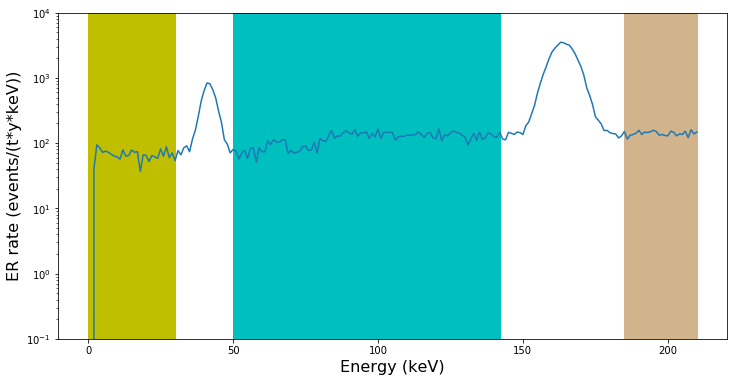

In [9]:
exposure = 0.65 #tonne-years

fig  = plt.figure(figsize=(12,6))
plt.xlabel('Energy (keV)', fontsize=16)
plt.ylabel('ER rate (events/(t*y*keV))', fontsize=16)
plt.axvspan(0, 30, color = 'y')
plt.axvspan(50, 142, color = 'c')
plt.axvspan(185, 210, color = 'tan')
rate_a = np.histogram(df_ER_a['energy'], bins=np.linspace(0,210,211))[0]/0.65 #(events/(t*y*keV))
rate_b = np.histogram(df_ER_b['energy'], bins=np.linspace(0,210,211))[0]/0.65 #(events/(t*y*keV))
rate = rate_a+rate_b
plt.plot(np.linspace(1,210,210), rate)
plt.yscale('log')
plt.ylim(0.1, 10000)
plt.show()

In [10]:
#difine bins

low_limit_l = 0
low_limit_u = 30
peak1_limit_l = 30
peak1_limit_u = 50
medium_limit_l = 50
medium_limit_u = 142
peak2_limit_l = 142
peak2_limit_u = 185
high_limit_l = 185
high_limit_u = 210

# Observed Rate

### Get information about datasets

In [7]:
sr1 = SR1()
runlist = sr1.runlist
dinfo = GW.dataset_info(runlist)
dinfo.calc_livetimes(runlist)
dinfo.n_Events(df_ER_a, df_ER_b)
dinfo.n_Events_low(df_ER_a, df_ER_b, low_limit_l, low_limit_u)
dinfo.n_Events_peak1(df_ER_a, df_ER_b, peak1_limit_l, peak1_limit_u)
dinfo.n_Events_medium(df_ER_a, df_ER_b, medium_limit_l, medium_limit_u)
dinfo.n_Events_peak2(df_ER_a, df_ER_b, peak2_limit_l, peak2_limit_u)
dinfo.n_Events_high(df_ER_a, df_ER_b, high_limit_l, high_limit_u)

100%|██████████| 5873/5873 [00:06<00:00, 920.77it/s]


## Rate of events

In [8]:
first_date = datetime(2017, 2, 2)
last_date = datetime(2018, 2, 7)
date_breaks = np.arange(first_date.timestamp(), last_date.timestamp()+24*3600, 24*3600)
datetime_breaks = []
for i in range(0, np.shape(date_breaks)[0]):
    datetime_breaks.append(datetime.fromtimestamp(date_breaks[i]))

100%|██████████| 371/371 [01:16<00:00,  3.53it/s]
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


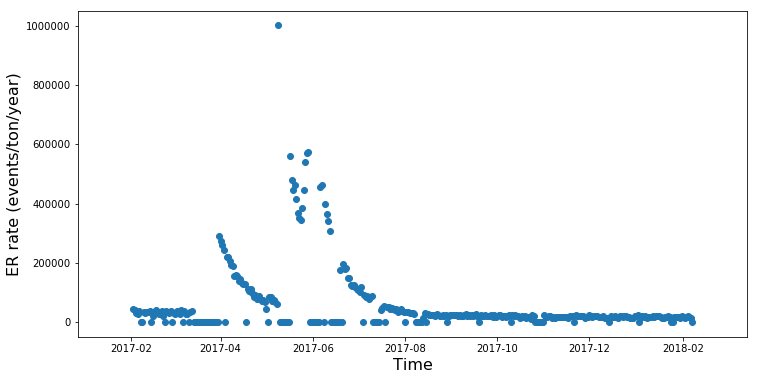

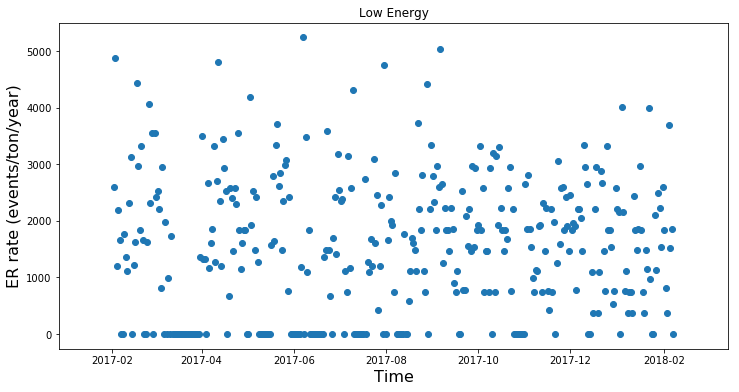

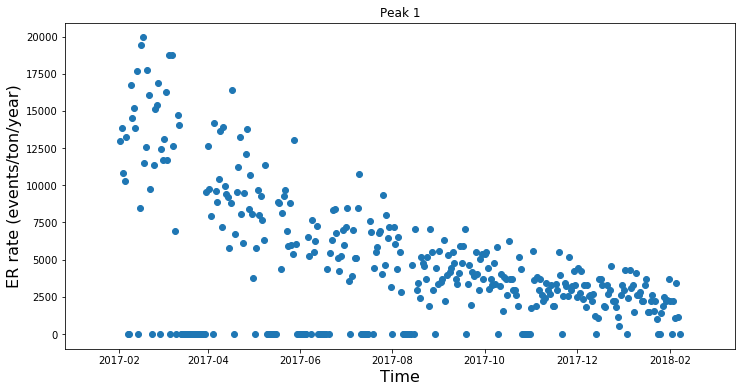

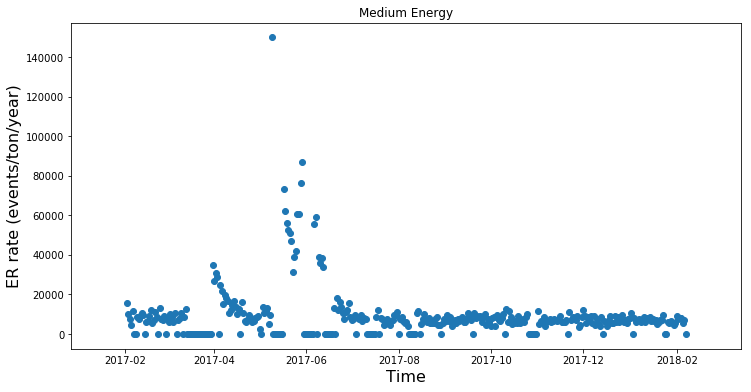

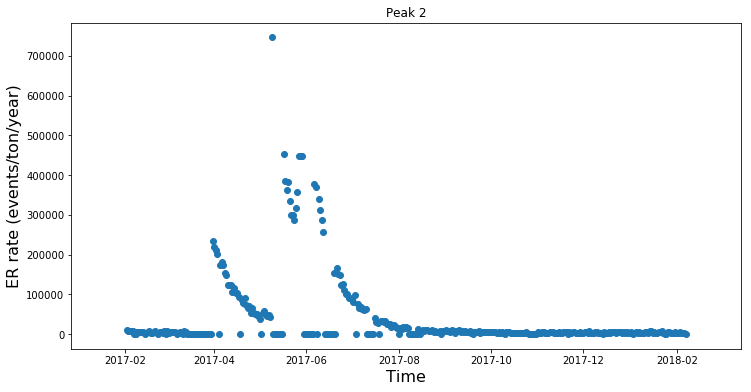

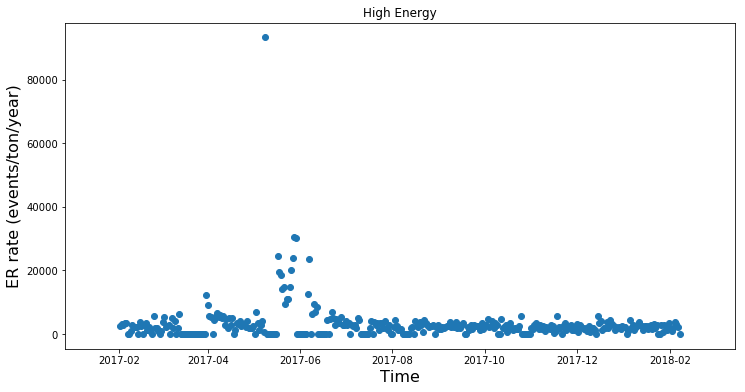

In [9]:
dinfo.calc_event_rate(date_breaks, runlist)

fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event)
plt.legend()
plt.show()

fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_l)
plt.title("Low Energy")
plt.legend()
plt.show()

fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_peak1)
plt.title("Peak 1")
plt.legend()
plt.show()

fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_m)
plt.title("Medium Energy")
plt.legend()
plt.show()

fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_peak2)
plt.title("Peak 2")
plt.legend()
plt.show()

fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_u)
plt.title("High Energy")
plt.legend()
plt.show()

# Background Model

### Finding livetime

In [11]:
Data['start_time'] = ''
Data['end_time'] = ''

dsets = dinfo.dsets
for j in range(0, np.shape(Data['Event_time'])[0]):
    Data['start_time'][j] = []
    Data['end_time'][j] = []
    for i in range(0, np.size(dsets.start)):
        delay_s = Data['Event_time'][j] - dsets.start[i].replace(tzinfo=timezone.utc).timestamp()
        if delay_s > 500 and delay_s<1500:
            Data['start_time'][j].append(dsets.start[i].replace(tzinfo=timezone.utc).timestamp())

        delay_e = Data['Event_time'][j] - dsets.end[i].replace(tzinfo=timezone.utc).timestamp()
        if delay_e > 500 and delay_e<1500:
            Data['end_time'][j].append(dsets.end[i].replace(tzinfo=timezone.utc).timestamp())

Data

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


,Event,Event_date,Event_time,start_time,end_time
0,GW170729,2017-07-29 18:56:29+00:00,1.501355e+09,[],[]
1,GW170817,2017-08-17 12:41:04+00:00,1.502974e+09,[],[]
2,GW170818,2017-08-18 02:25:09+00:00,1.503023e+09,[1503022261.0],[1503022254.0]
3,GW170823,2017-08-23 13:13:58+00:00,1.503494e+09,[],[]


In [12]:
Data['start_time']

0                []
1                []
2    [1503022261.0]
3                []
Name: start_time, dtype: object

In [13]:
np.shape(Data['start_time'][0])[0]

0

In [14]:
Data['end_time']

0                []
1                []
2    [1503022254.0]
3                []
Name: end_time, dtype: object

In [15]:
Data['missing_time'] = 0
for i in range(0, 3):
    for j in range(0, np.shape(Data['start_time'][i])[0]):
        Data['missing_time'][i] = Data['missing_time'][i] + Data['start_time'][i][j] - Data['end_time'][i][j]
Data['livetime'] = 1000 - Data['missing_time']
Data

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


,Event,Event_date,Event_time,start_time,end_time,missing_time,livetime
0,GW170729,2017-07-29 18:56:29+00:00,1.501355e+09,[],[],0,1000
1,GW170817,2017-08-17 12:41:04+00:00,1.502974e+09,[],[],0,1000
2,GW170818,2017-08-18 02:25:09+00:00,1.503023e+09,[1503022261.0],[1503022254.0],7,993
3,GW170823,2017-08-23 13:13:58+00:00,1.503494e+09,[],[],0,1000


In [16]:
Data['livetime']

0    1000
1    1000
2     993
3    1000
Name: livetime, dtype: int64

### Total - Across all energy

In [28]:
Fiducial_Volume = 0.65

In [20]:
signal = 'magnetic_moment'

with open('/project2/lgrandi/LowER/stats/limits/%s/limit_sr1_jq_mougeot.pkl' % signal, 'rb') as f:
    RESULTS = pickle.load(f)

print("Created on %s" %RESULTS["creation_time"])

RESULTS.keys()

nullfita = RESULTS['nullfit_partition_a']
nullfitb = RESULTS['nullfit_partition_b']

compsa = nullfita[1]
compsb = nullfitb[1]

comps = {}

for source, h in compsa.items():
    s = s2 = source
    suf = ''
    if '_0' in s:
        s = s.split('_0')[0]
        s2 = source.replace('_0', '_1')
    comps[s] = h + compsb[s2]
    
order = ["pb214", "kr85", "materials", "xe136", "solarnu", "xe133", "xe131m", "i125", "kr83m", "dec"]

for i in range(0, np.shape(order)[0]):
    print(order[i], sum(comps[order[i]].histogram * comps[order[i]].bin_volumes()))

Created on 2020-06-02 17:28:51.907648
pb214 7484.43930235
kr85 773.525295861
materials 322.627047212
xe136 2147.95261687
solarnu 221.001925753
xe133 4009.26990277
xe131m 24266.0776742
i125 83.9825928572
kr83m 2670.80051549
dec 149.507314477


In [17]:
eff = []
for i in range(1, 210):
    eff.append(efficiency(i,'sr1'))
    
eff

[0.1223688134210132,
 0.72934662889646484,
 0.85488072430094741,
 0.87448271074806794,
 0.88207497981367367,
 0.88421936766750286,
 0.8851529571857174,
 0.8859224500203996,
 0.88656696819743863,
 0.88710542683908788,
 0.8875538768078175,
 0.88792593985736545,
 0.88823317624963505,
 0.88848539673712923,
 0.88869092733053556,
 0.88885683399687221,
 0.88898911335222808,
 0.88909285449540998,
 0.88917237634998247,
 0.88923134422121197,
 0.88927286871349454,
 0.88929958967779799,
 0.88931374745465186,
 0.88931724333534889,
 0.88931169087305817,
 0.88929845942860664,
 0.88927871112611812,
 0.88925343221585407,
 0.88922345969065553,
 0.88918950387430151,
 0.88915216759138471,
 0.88911196243605128,
 0.88906932257865923,
 0.88902461648296116,
 0.88897815685002823,
 0.88893020905727971,
 0.8888809983203616,
 0.8888307157711629,
 0.88877952361599211,
 0.88872755951312554,
 0.88867494028786531,
 0.88862176508536639,
 0.88856811804631985,
 0.8885140705777036,
 0.88845968327988123,
 0.88840500758205

In [22]:
Eff = np.average(eff)
Eff

0.88014771447457785

In [34]:
days = np.linspace(0, 365, 366)
t0 = datetime(2017, 2, 4, 3, 52, 14, 293773)
dates = t0 + np.array([timedelta(days=d) for d in days])
timestamp = np.array([dt.timestamp() for dt in dates])

xe136_rate = sum(comps["xe136"].histogram * comps["xe136"].bin_volumes())
solarnu_rate = sum(comps["solarnu"].histogram * comps["solarnu"].bin_volumes())
pb214_rate = sum(comps["pb214"].histogram * comps["pb214"].bin_volumes())
materials_rate = sum(comps["materials"].histogram * comps["materials"].bin_volumes())
kr85_rate = sum(comps["kr85"].histogram * comps["kr85"].bin_volumes())
dec_rate = sum(comps["dec"].histogram * comps["dec"].bin_volumes())

i125 = bg.I125Model(runlist)
i125_rate = sum(comps["i125"].histogram * comps["i125"].bin_volumes())/(i125.calculate_rate()*Fiducial_Volume*Eff) * I125.I125_rate(days)

xe131m = bg.Xe131mModel(runlist)
xe131m_rate = sum(comps["xe131m"].histogram * comps["xe131m"].bin_volumes())/(xe131m.calculate_rate()*Fiducial_Volume*Eff) * bg.Xe131mModel.decay_func(timestamp)

kr83m = bg.Kr83mSourceClosed(runlist)
kr83m_rate = sum(comps["kr83m"].histogram * comps["kr83m"].bin_volumes())/(kr83m.calculate_rate()*Fiducial_Volume*Eff) * bg.Kr83mSourceClosed.kr83m_rate(days)

xe133 = bg.Xe133Model(runlist, energy_range=(80, 120))
xe133_rate = sum(comps["xe133"].histogram * comps["xe133"].bin_volumes())/(xe133.calculate_rate()*Fiducial_Volume*Eff) * bg.Xe133Model.decay_func(timestamp)

signal = xe136_rate + solarnu_rate + pb214_rate + materials_rate + kr85_rate + dec_rate + i125_rate + xe131m_rate + kr83m_rate + xe133_rate


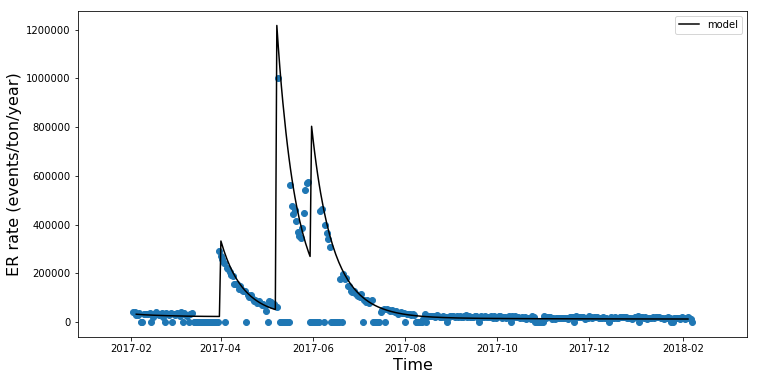

In [35]:
fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event)
plt.plot(dates, signal, label = 'model', color='black')
plt.legend()
plt.show()

In [36]:
#Expectation value for sideband time region

Data['Expected ER events (/year)'] = ''
for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (/year)'][j] = signal[i]
            
Data['Expected bkgd ER events'] = Data['Expected ER events (/year)']*Data['livetime']/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


In [37]:
Data['Expected bkgd ER events']

0     1.08637
1     0.66644
2    0.649913
3    0.603548
Name: Expected bkgd ER events, dtype: object

In [38]:
#Copied this function from LowER.background because I need to use function calculate_rate()

from LowER import THISDIR, analysis_range, full_path

class SolarnuBackground(bg.BackgroundModel):
    def calculate_rate(self, E_min = min(analysis_range), E_max = max(analysis_range)):
        """rate in analysis range, (1, 210) keV by default, in unit evts/t/year"""
        su = pickle.load(open(full_path('data/models/solarnu.pkl'), 'rb'))
        roi_mask = (su.bin_centers < E_max) & (su.bin_centers > E_min)
        rate = (su.bin_volumes()[roi_mask] * su.histogram[roi_mask]).sum()

        return rate

    def rate_uncertainty(self):
        """Gives the fractional rate uncertainty for this background"""
        # nt mc paper
        return 0.03


In [39]:
#Table 1 of lowER paper
rel_error_Pb = 160/7480
rel_error_Kr = 80/773
rel_error_materials = 0
rel_error_Xe136 = 120/2150
rel_error_solar = 4.7/220.8
rel_error_Xe133 = 85/4009
rel_error_Xe131m = 150/24270
rel_error_I125_K = 12/67
rel_error_I125_L = 2.3/13.1
rel_error_I125_M = 0.5/2.94
rel_error_Kr83m = 53/2671
rel_error_Xe124_KK = 24/113
rel_error_Xe124_KL = 7.3/34
rel_error_Xe124_LL = 0.55/2.56

### Low Energy

In [40]:
#low

eff = []
for i in range(1, 30):
    eff.append(efficiency(i,'sr1'))
    
eff

[0.1223688134210132,
 0.72934662889646484,
 0.85488072430094741,
 0.87448271074806794,
 0.88207497981367367,
 0.88421936766750286,
 0.8851529571857174,
 0.8859224500203996,
 0.88656696819743863,
 0.88710542683908788,
 0.8875538768078175,
 0.88792593985736545,
 0.88823317624963505,
 0.88848539673712923,
 0.88869092733053556,
 0.88885683399687221,
 0.88898911335222808,
 0.88909285449540998,
 0.88917237634998247,
 0.88923134422121197,
 0.88927286871349454,
 0.88929958967779799,
 0.88931374745465186,
 0.88931724333534889,
 0.88931169087305817,
 0.88929845942860664,
 0.88927871112611812,
 0.88925343221585407,
 0.88922345969065553]

In [42]:
Eff = 0.88

In [76]:
days = np.linspace(0, 365, 366)
t0 = datetime(2017, 2, 4, 3, 52, 14, 293773)
dates = t0 + np.array([timedelta(days=d) for d in days])
timestamp = np.array([dt.timestamp() for dt in dates])

idx = np.where((comps["pb214"].bin_centers < low_limit_u) & (comps["pb214"].bin_centers > low_limit_l))

xe136_rate = sum(comps["xe136"].histogram[idx] * comps["xe136"].bin_volumes()[idx])
solarnu_rate = sum(comps["solarnu"].histogram[idx] * comps["solarnu"].bin_volumes()[idx])
pb214_rate = sum(comps["pb214"].histogram[idx] * comps["pb214"].bin_volumes()[idx])
materials_rate = sum(comps["materials"].histogram[idx] * comps["materials"].bin_volumes()[idx])
kr85_rate = sum(comps["kr85"].histogram[idx] * comps["kr85"].bin_volumes()[idx])
dec_rate = sum(comps["dec"].histogram[idx] * comps["dec"].bin_volumes()[idx])

xe133 = bg.Xe133Model(runlist, energy_range=(80, 120))
xe133_rate = sum(comps["xe133"].histogram[idx] * comps["xe133"].bin_volumes()[idx])/(xe133.calculate_rate()*Fiducial_Volume*Eff) * bg.Xe133Model.decay_func(timestamp)

signal = xe136_rate + solarnu_rate + pb214_rate + materials_rate + kr85_rate + dec_rate + xe133_rate
uncertainty = xe136_rate * rel_error_Xe136 + solarnu_rate * rel_error_solar + pb214_rate * rel_error_Pb + kr85_rate * rel_error_Kr + dec_rate * rel_error_Xe124_LL + xe133_rate * rel_error_Xe133

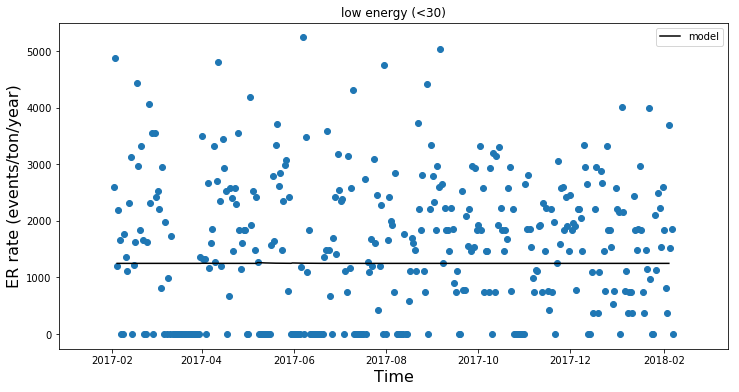

In [77]:
fig  = plt.figure(figsize=(12,6))
plt.title("low energy (<30)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_l)
plt.plot(dates, signal, label = 'model', color='black')

plt.legend()
plt.show()

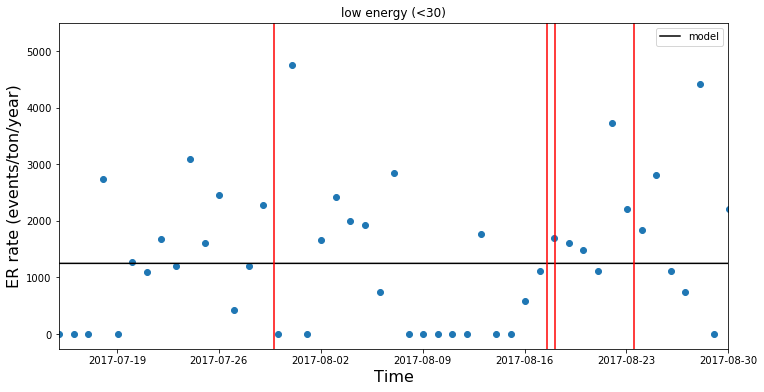

In [78]:
fig  = plt.figure(figsize=(12,6))
plt.title("low energy (<30)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_l)
plt.plot(dates, signal, label = 'model', color='black')

plt.axvline(GW_8_23_datetime, color='red')
plt.axvline(GW_8_18_datetime, color='red')
plt.axvline(GW_8_17_datetime, color='red')
plt.axvline(GW_7_29_datetime, color='red')
plt.xlim(datetime(2017, 7, 15), datetime(2017, 8, 30))

plt.legend()
plt.show()

In [79]:
#Expectation value for sideband time region

Data['Expected ER events (low) (/year)'] = ''
Data['systematic uncertainty (low) (/year)'] = ''

for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (low) (/year)'][j] = signal[i]
            Data['systematic uncertainty (low) (/year)'][j] = uncertainty[i]
            
Data['Expected bkgd ER events (low)'] = Data['Expected ER events (low) (/year)']*Data['livetime']/(365*60*60*24)
Data['systematic uncertainty (low)'] = Data['systematic uncertainty (low) (/year)']*1000/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


In [80]:
Data['Expected bkgd ER events (low)']

0    0.0395695
1    0.0395693
2    0.0392924
3    0.0395693
Name: Expected bkgd ER events (low), dtype: object

In [81]:
Data['systematic uncertainty (low)']

0    0.00116288
1    0.00116287
2    0.00116287
3    0.00116287
Name: systematic uncertainty (low), dtype: object

### Peak 1

In [82]:
#peak1

eff = []
for i in range(30, 50):
    eff.append(efficiency(i,'sr1'))
    
Eff = np.average(eff)

In [83]:
days = np.linspace(0, 365, 366)
t0 = datetime(2017, 2, 4, 3, 52, 14, 293773)
dates = t0 + np.array([timedelta(days=d) for d in days])
timestamp = np.array([dt.timestamp() for dt in dates])

idx = np.where((comps["pb214"].bin_centers < peak1_limit_u) & (comps["pb214"].bin_centers > peak1_limit_l))

xe136_rate = sum(comps["xe136"].histogram[idx] * comps["xe136"].bin_volumes()[idx])
solarnu_rate = sum(comps["solarnu"].histogram[idx] * comps["solarnu"].bin_volumes()[idx])
pb214_rate = sum(comps["pb214"].histogram[idx] * comps["pb214"].bin_volumes()[idx])
materials_rate = sum(comps["materials"].histogram[idx] * comps["materials"].bin_volumes()[idx])
kr85_rate = sum(comps["kr85"].histogram[idx] * comps["kr85"].bin_volumes()[idx])
dec_rate = sum(comps["dec"].histogram[idx] * comps["dec"].bin_volumes()[idx])

i125 = bg.I125Model(runlist)
i125_rate = sum(comps["i125"].histogram[idx] * comps["i125"].bin_volumes()[idx])/(i125.calculate_rate()*Fiducial_Volume*Eff) * I125.I125_rate(days)

kr83m = bg.Kr83mSourceClosed(runlist)
kr83m_rate = sum(comps["kr83m"].histogram[idx] * comps["kr83m"].bin_volumes()[idx])/(kr83m.calculate_rate()*Fiducial_Volume*Eff) * bg.Kr83mSourceClosed.kr83m_rate(days)

xe133 = bg.Xe133Model(runlist, energy_range=(80, 120))
xe133_rate = sum(comps["xe133"].histogram[idx] * comps["xe133"].bin_volumes()[idx])/(xe133.calculate_rate()*Fiducial_Volume*Eff) * bg.Xe133Model.decay_func(timestamp)

signal = xe136_rate + solarnu_rate + pb214_rate + materials_rate + kr85_rate + dec_rate + i125_rate + kr83m_rate + xe133_rate
uncertainty = xe136_rate * rel_error_Xe136 + solarnu_rate * rel_error_solar + pb214_rate * rel_error_Pb + kr85_rate * rel_error_Kr + dec_rate * rel_error_Xe124_LL + i125_rate * rel_error_I125_L + kr83m_rate * rel_error_Kr83m + xe133_rate * rel_error_Xe133

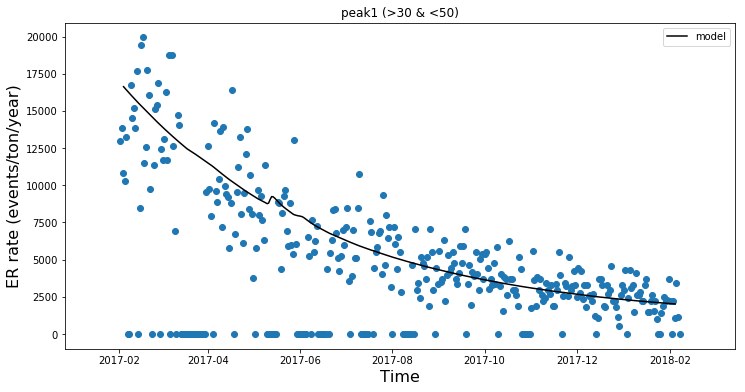

In [84]:
fig  = plt.figure(figsize=(12,6))
plt.title("peak1 (>30 & <50)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_peak1)
plt.plot(dates, signal, label = 'model', color='black')

plt.legend()
plt.show()

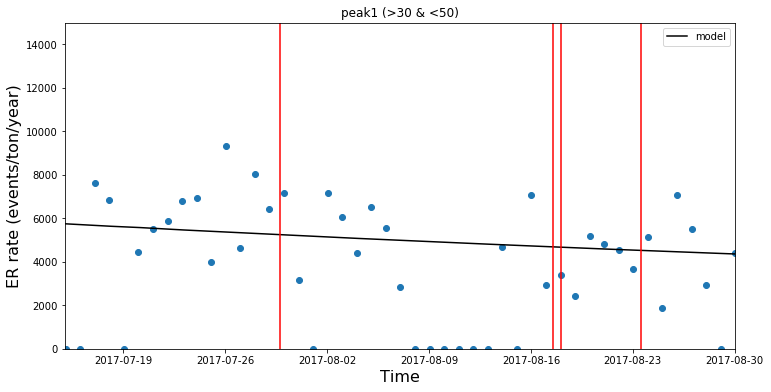

In [85]:
fig  = plt.figure(figsize=(12,6))
plt.title("peak1 (>30 & <50)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_peak1)

plt.plot(dates, signal, label = 'model', color='black')

plt.ylim(0, 15000)
plt.xlim(datetime(2017, 7, 15), datetime(2017, 8, 30))

plt.axvline(GW_8_23_datetime, color='red')
plt.axvline(GW_8_18_datetime, color='red')
plt.axvline(GW_8_17_datetime, color='red')
plt.axvline(GW_7_29_datetime, color='red')

plt.legend()
plt.show()

In [86]:
#Expectation value for sideband time region

Data['Expected ER events (peak1) (/year)'] = ''
Data['systematic uncertainty (peak1) (/year)'] = ''

for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (peak1) (/year)'][j] = signal[i]
            Data['systematic uncertainty (peak1) (/year)'][j] = uncertainty[i]

Data['Expected bkgd ER events (peak1)'] = Data['Expected ER events (peak1) (/year)']*Data['livetime']/(365*60*60*24)
Data['systematic uncertainty (peak1)'] = Data['systematic uncertainty (peak1) (/year)']*1000/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


In [87]:
Data['Expected bkgd ER events (peak1)']

0    0.166912
1    0.148915
2    0.147013
3     0.14379
Name: Expected bkgd ER events (peak1), dtype: object

In [88]:
Data['systematic uncertainty (peak1)']

0    0.00383933
1    0.00346318
2    0.00344718
3    0.00336432
Name: systematic uncertainty (peak1), dtype: object

### Medium Energy

In [90]:
#medium

eff = []
for i in range(50, 142):
    eff.append(efficiency(i,'sr1'))
    
Eff = np.average(eff)

In [91]:
days = np.linspace(0, 365, 366)
t0 = datetime(2017, 2, 4, 3, 52, 14, 293773)
dates = t0 + np.array([timedelta(days=d) for d in days])
timestamp = np.array([dt.timestamp() for dt in dates])

idx = np.where((comps["pb214"].bin_centers < medium_limit_u) & (comps["pb214"].bin_centers > medium_limit_l))

xe136_rate = sum(comps["xe136"].histogram[idx] * comps["xe136"].bin_volumes()[idx])
solarnu_rate = sum(comps["solarnu"].histogram[idx] * comps["solarnu"].bin_volumes()[idx])
pb214_rate = sum(comps["pb214"].histogram[idx] * comps["pb214"].bin_volumes()[idx])
materials_rate = sum(comps["materials"].histogram[idx] * comps["materials"].bin_volumes()[idx])
kr85_rate = sum(comps["kr85"].histogram[idx] * comps["kr85"].bin_volumes()[idx])
dec_rate = sum(comps["dec"].histogram[idx] * comps["dec"].bin_volumes()[idx])

i125 = bg.I125Model(runlist)
i125_rate = sum(comps["i125"].histogram[idx] * comps["i125"].bin_volumes()[idx])/(i125.calculate_rate()*Fiducial_Volume*Eff) * I125.I125_rate(days)

xe133 = bg.Xe133Model(runlist, energy_range=(80, 120))
xe133_rate = sum(comps["xe133"].histogram[idx] * comps["xe133"].bin_volumes()[idx])/(xe133.calculate_rate()*Fiducial_Volume*Eff) * bg.Xe133Model.decay_func(timestamp)

signal = xe136_rate + solarnu_rate + pb214_rate + materials_rate + kr85_rate + dec_rate + i125_rate + xe133_rate
uncertainty = xe136_rate * rel_error_Xe136 + solarnu_rate * rel_error_solar + pb214_rate * rel_error_Pb + kr85_rate * rel_error_Kr + dec_rate * rel_error_Xe124_KK + i125_rate * rel_error_I125_K + xe133_rate * rel_error_Xe133

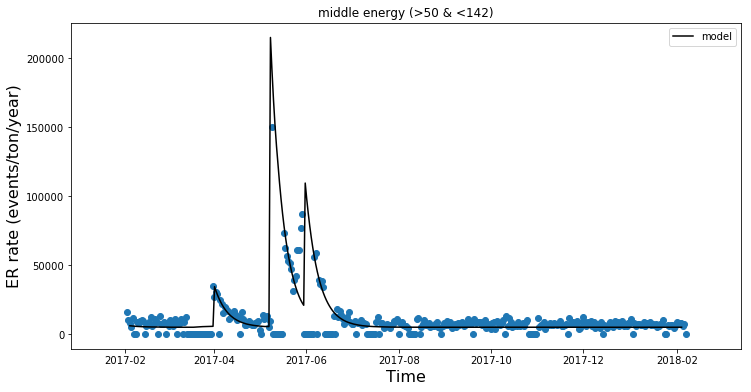

In [92]:
fig  = plt.figure(figsize=(12,6))
plt.title("middle energy (>50 & <142)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_m)

plt.plot(dates, signal, label = 'model', color='black')
plt.legend()
plt.show()

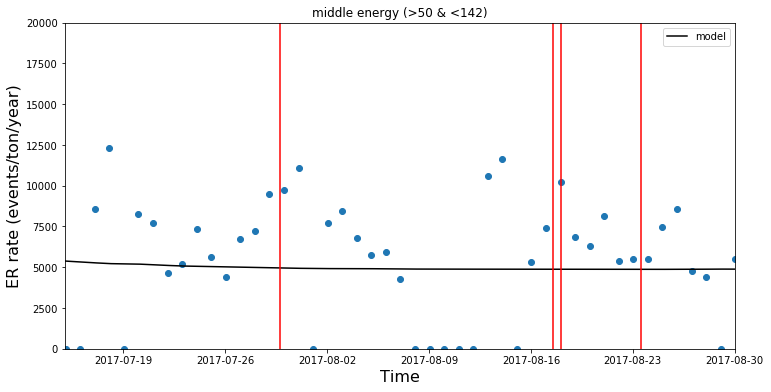

In [93]:
fig  = plt.figure(figsize=(12,6))
plt.title("middle energy (>50 & <142)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_m)

plt.plot(dates, signal, label = 'model', color='black')

plt.ylim(0, 20000)
plt.xlim(datetime(2017, 7, 15), datetime(2017, 8, 30))

plt.axvline(GW_8_23_datetime, color='red')
plt.axvline(GW_8_18_datetime, color='red')
plt.axvline(GW_8_17_datetime, color='red')
plt.axvline(GW_7_29_datetime, color='red')

plt.legend()
plt.show()

In [94]:
#Expectation value for sideband time region

Data['Expected ER events (medium) (/year)'] = ''
Data['systematic uncertainty (medium) (/year)'] = ''

for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (medium) (/year)'][j] = signal[i]
            Data['systematic uncertainty (medium) (/year)'][j] = uncertainty[i]
            
Data['Expected bkgd ER events (medium)'] = Data['Expected ER events (medium) (/year)']*Data['livetime']/(365*60*60*24)
Data['systematic uncertainty (medium)'] = Data['systematic uncertainty (medium) (/year)']*1000/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


In [95]:
Data['Expected bkgd ER events (medium)']

0    0.157376
1    0.154513
2    0.153434
3    0.154455
Name: Expected bkgd ER events (medium), dtype: object

In [96]:
Data['systematic uncertainty (medium)']

0    0.00583926
1    0.00569749
2    0.00570255
3    0.00570834
Name: systematic uncertainty (medium), dtype: object

### Peak 2

In [104]:
#medium

eff = []
for i in range(142, 185):
    eff.append(efficiency(i,'sr1'))

np.average(eff)

0.88182780031580277

In [105]:
Xe133 = bg.Xe133Model(runlist, energy_range=(80, 120))
Xe133_r = bg.Xe133Model(runlist, energy_range=(142, 185))
Xe136 = bg.Xe136Model(runlist, energy_range=(142, 185))

solar_v = SolarnuBackground(runlist)
material = bg.MaterialsBackground(runlist)
Kr85 = bg.Kr85Background(runlist)
Pb214 =bg.Pb214Background(runlist)

signal = (bg.Xe131mModel.decay_func(timestamp) + bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + Xe136.calculate_rate() + solar_v.calculate_rate(142, 185) + material.calculate_rate() * (185-142)/210 + Kr85.calculate_rate() * (185-142)/210 + Pb214.calculate_rate() * (185-142)/210) * 0.88
uncertainty = (bg.Xe131mModel.decay_func(timestamp) * rel_error_Xe131m + rel_error_Xe133 * bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + rel_error_Xe136 * Xe136.calculate_rate() + rel_error_solar * solar_v.calculate_rate(142, 185) + rel_error_Kr * Kr85.calculate_rate() * (185-142)/210 + rel_error_Pb * Pb214.calculate_rate() * (185-142)/210) * 0.88

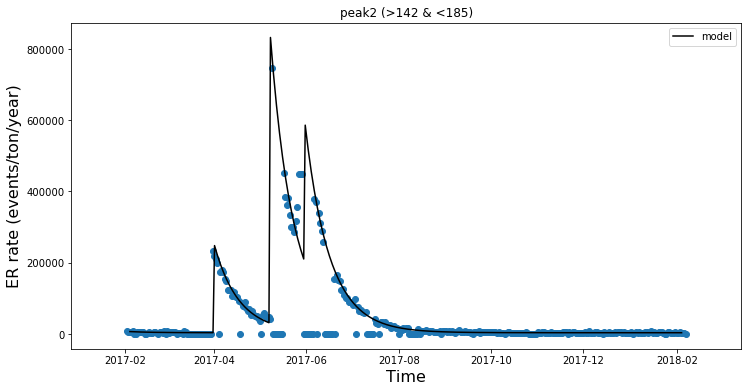

In [108]:
fig  = plt.figure(figsize=(12,6))
plt.title("peak2 (>142 & <185)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_peak2)

plt.plot(dates, signal, label = 'model', color='black')

plt.legend()
plt.show()

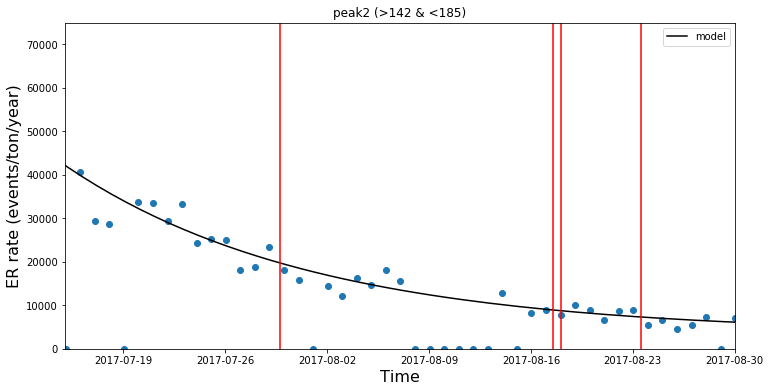

In [109]:
fig  = plt.figure(figsize=(12,6))
plt.title("peak2 (>142 & <185)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_peak2)

plt.plot(dates, signal, label = 'model', color='black')

plt.xlim(datetime(2017, 7, 15), datetime(2017, 8, 30))
plt.ylim(0, 75000)

plt.axvline(GW_8_23_datetime, color='red')
plt.axvline(GW_8_18_datetime, color='red')
plt.axvline(GW_8_17_datetime, color='red')
plt.axvline(GW_7_29_datetime, color='red')

plt.legend()
plt.show()

In [110]:
#Expectation value for sideband time region

Data['Expected ER events (peak2) (/year)'] = ''
Data['systematic uncertainty (peak2) (/year)'] = ''

for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (peak2) (/year)'][j] = signal[i]
            Data['systematic uncertainty (peak2) (/year)'][j] = uncertainty[i]
            
Data['Expected bkgd ER events (peak2)'] = Data['Expected ER events (peak2) (/year)']*Data['livetime']/(365*60*60*24)
Data['systematic uncertainty (peak2)'] = Data['systematic uncertainty (peak2) (/year)']*1000/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


In [126]:
Data['Expected bkgd ER events (peak2)']

0    0.644518
1    0.286521
2    0.274637
3    0.234717
Name: Expected bkgd ER events (peak2), dtype: object

In [141]:
Data['systematic uncertainty (peak2)']

0    0.00759021
1    0.00536018
2    0.00529848
3      0.005039
Name: systematic uncertainty (peak2), dtype: object

### High Energy

In [111]:
#medium

eff = []
for i in range(185, 210):
    eff.append(efficiency(i,'sr1'))

np.average(eff)

0.87991383965241698

In [112]:
Xe133 = bg.Xe133Model(runlist, energy_range=(80, 120))
Xe133_r = bg.Xe133Model(runlist, energy_range=(185, 210))
Xe136 = bg.Xe136Model(runlist, energy_range=(185, 210))

solar_v = SolarnuBackground(runlist)
material = bg.MaterialsBackground(runlist)
Kr85 = bg.Kr85Background(runlist)
Pb214 =bg.Pb214Background(runlist)

signal = (bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + Xe136.calculate_rate() + solar_v.calculate_rate(185, 210) + material.calculate_rate() * (210-185)/210 + Kr85.calculate_rate() * (210-185)/210 + Pb214.calculate_rate() * (210-185)/210) * 0.88
uncertainty = (rel_error_Xe133 * bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + rel_error_Xe136 * Xe136.calculate_rate() + rel_error_solar * solar_v.calculate_rate(185, 210) + rel_error_Kr * Kr85.calculate_rate() * (210-185)/210 + rel_error_Pb * Pb214.calculate_rate() * (210-185)/210) * 0.88

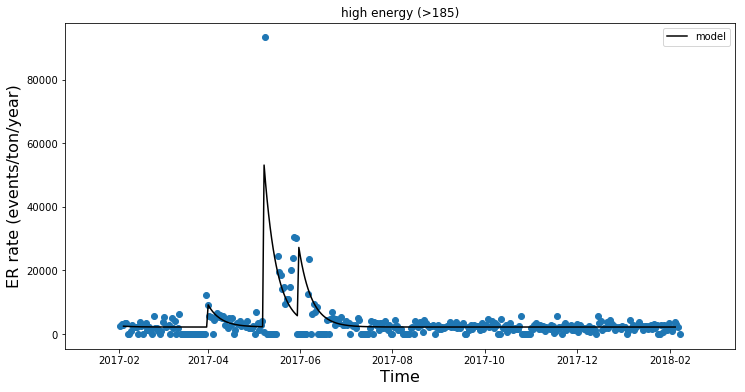

In [113]:
fig  = plt.figure(figsize=(12,6))
plt.title("high energy (>185)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_u)

plt.plot(dates, signal, label = 'model', color='black')

plt.legend()
plt.show()

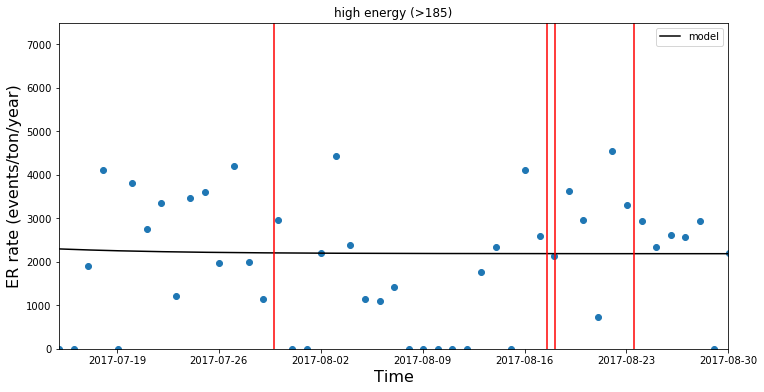

In [114]:
fig  = plt.figure(figsize=(12,6))
plt.title("high energy (>185)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, dinfo.rate_event_u)

plt.plot(dates, signal, label = 'model', color='black')

plt.ylim(0, 7500)
plt.xlim(datetime(2017, 7, 15), datetime(2017, 8, 30))

plt.axvline(GW_8_23_datetime, color='red')
plt.axvline(GW_8_18_datetime, color='red')
plt.axvline(GW_8_17_datetime, color='red')
plt.axvline(GW_7_29_datetime, color='red')

plt.legend()
plt.show()

In [115]:
#Expectation value for sideband time region

Data['Expected ER events (high) (/year)'] = ''
Data['systematic uncertainty (high) (/year)'] = ''

for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (high) (/year)'][j] = signal[i]
            Data['systematic uncertainty (high) (/year)'][j] = uncertainty[i]

Data['Expected bkgd ER events (high)'] = Data['Expected ER events (high) (/year)']*Data['livetime']/(365*60*60*24)
Data['systematic uncertainty (high)'] = Data['systematic uncertainty (high) (/year)']*1000/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


In [127]:
Data['Expected bkgd ER events (high)']

0    0.0699648
1    0.0693945
2    0.0689015
3    0.0693616
Name: Expected bkgd ER events (high), dtype: object

In [140]:
Data['systematic uncertainty (high)']

0    0.00275106
1    0.00273897
2    0.00273881
3    0.00273827
Name: systematic uncertainty (high), dtype: object

# Sideband time regions

In [116]:
#ER_a is not in time of target GWs

ER_b_l = df_ER_b[(df_ER_b['energy']<=30)]
ER_b_p1 = df_ER_b[(df_ER_b['energy']<50) & (df_ER_b['energy']>30)]
ER_b_m = df_ER_b[(df_ER_b['energy']<=142) & (df_ER_b['energy']>=50)]
ER_b_p2 = df_ER_b[(df_ER_b['energy']>142) & (df_ER_b['energy']<185)]
ER_b_h = df_ER_b[(df_ER_b['energy']>=185)]

Data['n_ER'] = 0
Data['n_ER_l'] = 0
Data['n_ER_p1'] = 0
Data['n_ER_m'] = 0
Data['n_ER_p2'] = 0
Data['n_ER_h'] = 0

for j in range(0, np.shape(Data['Event_time'])[0]):
    for i in range(0, np.shape(df_ER_b['event_time'])[0]):
        id = df_ER_b.index[i]
        delay = Data['Event_time'][j] - df_ER_b['event_time'][id]*1e-9 
        if delay > 500 and delay<1500:
            Data['n_ER'][j] = Data['n_ER'][j] + 1
            
    for i in range(0, np.shape(ER_b_l['event_time'])[0]):
        id = ER_b_l.index[i]
        delay = Data['Event_time'][j] - ER_b_l['event_time'][id]*1e-9 
        if delay > 500 and delay<1500:
            Data['n_ER_l'][j] = Data['n_ER_l'][j] + 1

    for i in range(0, np.shape(ER_b_p1['event_time'])[0]):
        id = ER_b_p1.index[i]
        delay = Data['Event_time'][j] - ER_b_p1['event_time'][id]*1e-9 
        if delay > 500 and delay<1500:
            Data['n_ER_p1'][j] = Data['n_ER_p1'][j] + 1
            
    for i in range(0, np.shape(ER_b_m['event_time'])[0]):
        id = ER_b_m.index[i]
        delay = Data['Event_time'][j] - ER_b_m['event_time'][id]*1e-9 
        if delay > 500 and delay<1500:
            Data['n_ER_m'][j] = Data['n_ER_m'][j] + 1
            
    for i in range(0, np.shape(ER_b_p2['event_time'])[0]):
        id = ER_b_p2.index[i]
        delay = Data['Event_time'][j] - ER_b_p2['event_time'][id]*1e-9 
        if delay > 500 and delay<1500:
            Data['n_ER_p2'][j] = Data['n_ER_p2'][j] + 1
            
    for i in range(0, np.shape(ER_b_h['event_time'])[0]):
        id = ER_b_h.index[i]
        delay = Data['Event_time'][j] - ER_b_h['event_time'][id]*1e-9 
        if delay > 500 and delay<1500:
            Data['n_ER_h'][j] = Data['n_ER_h'][j] + 1
            
Data

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-cop

,Event,Event_date,Event_time,Expected ER events (/year),missing_time,start_time,end_time,livetime,Expected bkgd ER events,Expected ER events (low) (/year),...,Expected ER events (high) (/year),systematic uncertainty (high) (/year),Expected bkgd ER events (high),systematic uncertainty (high),n_ER,n_ER_l,n_ER_p1,n_ER_m,n_ER_p2,n_ER_h
0,GW170729,2017-07-29 18:56:29+00:00,1.501355e+09,36189.2,0,[],[],1000,1.14755,1830.79,...,2206.41,86.7575,0.0699648,0.00275106,1,0,0,1,0,0
1,GW170817,2017-08-17 12:41:04+00:00,1.502974e+09,24389.1,0,[],[],1000,0.773375,1830.78,...,2188.42,86.3761,0.0693945,0.00273897,0,0,0,0,0,0
2,GW170818,2017-08-18 02:25:09+00:00,1.503023e+09,24052.6,7,[1503022261.0],[1503022254.0],993,0.757365,1830.78,...,2188.2,86.3713,0.0689015,0.00273881,1,0,0,0,1,0
3,GW170823,2017-08-23 13:13:58+00:00,1.503494e+09,22617.5,0,[],[],1000,0.717196,1830.78,...,2187.39,86.3541,0.0693616,0.00273827,0,0,0,0,0,0


In [102]:
Data['Expected bkgd ER events (high)']

0     0.069557
1    0.0693535
2    0.0688654
3    0.0693417
Name: Expected bkgd ER events (high), dtype: object

# Predictions for 1000 seconds time window

In [117]:
Data['Expected bkgd ER events (/1000s)'] = Data['Expected ER events (/year)']*1000/(365*60*60*24)
Data['Expected bkgd ER events (low) (/1000s)'] = Data['Expected ER events (low) (/year)']*1000/(365*60*60*24)
Data['Expected bkgd ER events (peak1) (/1000s)'] = Data['Expected ER events (peak1) (/year)']*1000/(365*60*60*24)
Data['Expected bkgd ER events (medium) (/1000s)'] = Data['Expected ER events (medium) (/year)']*1000/(365*60*60*24)
Data['Expected bkgd ER events (peak2) (/1000s)'] = Data['Expected ER events (peak2) (/year)']*1000/(365*60*60*24)
Data['Expected bkgd ER events (high) (/1000s)'] = Data['Expected ER events (high) (/year)']*1000/(365*60*60*24)

#Poisson fluctuation
Data['statistical uncertainty (high)'] = Data['Expected bkgd ER events (high) (/1000s)'] ** 0.5
Data['statistical uncertainty (peak2)'] = Data['Expected bkgd ER events (peak2) (/1000s)'] ** 0.5
Data['statistical uncertainty (medium)'] = Data['Expected bkgd ER events (medium) (/1000s)'] ** 0.5
Data['statistical uncertainty (peak1)'] = Data['Expected bkgd ER events (peak1) (/1000s)'] ** 0.5
Data['statistical uncertainty (low)'] = Data['Expected bkgd ER events (low) (/1000s)'] ** 0.5

Data['P_no_obs'] = ''
Data['P_no_obs_high'] = ''
Data['P_no_obs_low'] = ''
Data['P_no_obs_medium'] = ''
Data['P_no_obs_peak1'] = ''
Data['P_no_obs_peak2'] = ''

for i in range(0,4):
    Data['P_no_obs'][i] = poisson.cdf(0, Data['Expected bkgd ER events (/1000s)'][i])
    Data['P_no_obs_high'][i] = poisson.cdf(0, Data['Expected bkgd ER events (high) (/1000s)'][i])
    Data['P_no_obs_low'][i] = poisson.cdf(0, Data['Expected bkgd ER events (low) (/1000s)'][i])
    Data['P_no_obs_medium'][i] = poisson.cdf(0, Data['Expected bkgd ER events (medium) (/1000s)'][i])
    Data['P_no_obs_peak1'][i] = poisson.cdf(0, Data['Expected bkgd ER events (peak1) (/1000s)'][i])
    Data['P_no_obs_peak2'][i] = poisson.cdf(0, Data['Expected bkgd ER events (peak2) (/1000s)'][i])
    


/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-cop

In [128]:
Data['P_no_obs']

0    0.317413
1    0.461453
2    0.466404
3    0.488119
Name: P_no_obs, dtype: object

In [129]:
Data['P_no_obs_high']

0    0.932427
1    0.932959
2    0.932965
3    0.932989
Name: P_no_obs_high, dtype: object

In [130]:
Data['P_no_obs_low']

0    0.943599
1    0.943599
2    0.943599
3    0.943599
Name: P_no_obs_low, dtype: object

In [131]:
Data['P_no_obs_medium']

0    0.802399
1    0.804382
2    0.804381
3    0.804423
Name: P_no_obs_medium, dtype: object

In [132]:
Data['P_no_obs_peak1']

0    0.849894
1    0.863357
2    0.864012
3    0.867238
Name: P_no_obs_peak1, dtype: object

In [133]:
Data['P_no_obs_peak2']

0    0.524915
1    0.750871
2    0.758378
3    0.790795
Name: P_no_obs_peak2, dtype: object

In [139]:
Data['statistical uncertainty (low)']

0    0.240944
1    0.240943
2    0.240943
3    0.240943
Name: statistical uncertainty (low), dtype: object

In [135]:
Data['statistical uncertainty (peak1)']

0    0.403291
1     0.38331
2     0.38232
3    0.377415
Name: statistical uncertainty (peak1), dtype: object

In [136]:
Data['statistical uncertainty (medium)']

0    0.469201
1    0.466563
2    0.466565
3    0.466509
Name: statistical uncertainty (medium), dtype: object

In [138]:
Data['statistical uncertainty (peak2)']

0    0.802819
1    0.535277
2    0.525902
3    0.484476
Name: statistical uncertainty (peak2), dtype: object

In [137]:
Data['statistical uncertainty (high)']

0    0.264509
1    0.263428
2    0.263415
3    0.263366
Name: statistical uncertainty (high), dtype: object

In [118]:
#90% confidence level
#20 independent bins

alpha = 1-(1-0.003)**(1/20) #Sidak Correction

Data['upper limit stat (low)'] = ''
Data['upper limit stat (peak1)'] = ''
Data['upper limit stat (medium)'] = ''
Data['upper limit stat (peak2)'] = ''
Data['upper limit stat (high)'] = ''

for i in range(0, 4):
    Data['upper limit stat (low)'][i] = poisson(mu=Data['Expected bkgd ER events (low) (/1000s)'][i]).ppf(1-alpha)
    Data['upper limit stat (peak1)'][i] = poisson(mu=Data['Expected bkgd ER events (peak1) (/1000s)'][i]).ppf(1-alpha)
    Data['upper limit stat (medium)'][i] = poisson(mu=Data['Expected bkgd ER events (medium) (/1000s)'][i]).ppf(1-alpha)
    Data['upper limit stat (peak2)'][i] = poisson(mu=Data['Expected bkgd ER events (peak2) (/1000s)'][i]).ppf(1-alpha)
    Data['upper limit stat (high)'][i] = poisson(mu=Data['Expected bkgd ER events (high) (/1000s)'][i]).ppf(1-alpha)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-cop

In [145]:
Data['upper limit stat (high)']

0    2
1    2
2    2
3    2
Name: upper limit stat (high), dtype: object

In [146]:
Data['upper limit stat (peak2)'] 

0    5
1    4
2    4
3    3
Name: upper limit stat (peak2), dtype: object

In [147]:
Data['upper limit stat (medium)'] 

0    3
1    3
2    3
3    3
Name: upper limit stat (medium), dtype: object

In [148]:
Data['upper limit stat (peak1)'] 

0    3
1    3
2    3
3    3
Name: upper limit stat (peak1), dtype: object

In [149]:
Data['upper limit stat (low)'] 

0    2
1    2
2    2
3    2
Name: upper limit stat (low), dtype: object

# Time region of interest

In [13]:
#ER_a is not in time of target GWs

ER_b_l = df_ER_b[(df_ER_b['energy']<=30)]
ER_b_p1 = df_ER_b[(df_ER_b['energy']<50) & (df_ER_b['energy']>30)]
ER_b_m = df_ER_b[(df_ER_b['energy']<=142) & (df_ER_b['energy']>=50)]
ER_b_p2 = df_ER_b[(df_ER_b['energy']>142) & (df_ER_b['energy']<185)]
ER_b_h = df_ER_b[(df_ER_b['energy']>=185)]

Data['n_ER'] = 0
Data['n_ER_l'] = 0
Data['n_ER_p1'] = 0
Data['n_ER_m'] = 0
Data['n_ER_p2'] = 0
Data['n_ER_h'] = 0

for j in range(0, np.shape(Data['Event_time'])[0]):
    for i in range(0, np.shape(df_ER_b['event_time'])[0]):
        id = df_ER_b.index[i]
        delay = abs(Data['Event_time'][j] - df_ER_b['event_time'][id])*1e-9 
        if delay < 500:
            Data['n_ER'][j] = Data['n_ER'][j] + 1
            
    for i in range(0, np.shape(ER_b_l['event_time'])[0]):
        id = ER_b_l.index[i]
        delay = abs(Data['Event_time'][j] - ER_b_l['event_time'][id])*1e-9 
        if delay < 500:
            Data['n_ER_l'][j] = Data['n_ER_l'][j] + 1

    for i in range(0, np.shape(ER_b_p1['event_time'])[0]):
        id = ER_b_p1.index[i]
        delay = abs(Data['Event_time'][j] - ER_b_p1['event_time'][id])*1e-9 
        if delay < 500:
            Data['n_ER_p1'][j] = Data['n_ER_p1'][j] + 1
            
    for i in range(0, np.shape(ER_b_m['event_time'])[0]):
        id = ER_b_m.index[i]
        delay = abs(Data['Event_time'][j] - ER_b_m['event_time'][id])*1e-9 
        if delay < 500:
            Data['n_ER_m'][j] = Data['n_ER_m'][j] + 1
            
    for i in range(0, np.shape(ER_b_p2['event_time'])[0]):
        id = ER_b_p2.index[i]
        delay = abs(Data['Event_time'][j] - ER_b_p2['event_time'][id])*1e-9 
        if delay < 500:
            Data['n_ER_p2'][j] = Data['n_ER_p2'][j] + 1
            
    for i in range(0, np.shape(ER_b_h['event_time'])[0]):
        id = ER_b_h.index[i]
        delay = abs(Data['Event_time'][j] - ER_b_h['event_time'][id])*1e-9 
        if delay < 500:
            Data['n_ER_h'][j] = Data['n_ER_h'][j] + 1
            
Data

,Event,Event_date,Event_time,n_ER,n_ER_l,n_ER_p1,n_ER_m,n_ER_p2,n_ER_h
0,GW170729,2017-07-29 18:56:29+00:00,1.501355e+09,0,0,0,0,0,0
1,GW170817,2017-08-17 12:41:04+00:00,1.502974e+09,0,0,0,0,0,0
2,GW170818,2017-08-18 02:25:09+00:00,1.503023e+09,0,0,0,0,0,0
3,GW170823,2017-08-23 13:13:58+00:00,1.503494e+09,0,0,0,0,0,0


# Poisson Verification

In [69]:
df_ER = df_ER_b
df_ER = df_ER.append(df_ER_a)
df_ER = df_ER.sort_values(by='event_time')
df_ER['energy'] = df_ER['ces']

In [70]:
'''
dt_ER = []

for i in tqdm(range(0, np.shape(df_ER)[0]-1)):
        dt_ER.append((df_ER['event_time'].values[i+1]-df_ER['event_time'].values[j])*1e-9)
        
'''

"\ndt_ER = []\n\nfor i in tqdm(range(0, np.shape(df_ER)[0]-1)):\n        dt_ER.append((df_ER['event_time'].values[i+1]-df_ER['event_time'].values[j])*1e-9)\n        \n"

In [71]:
dt_ER = []
j = 5872
i = 0

for i in tqdm(range(0, np.shape(df_ER)[0]-1)):
    start = dsets.start[j].replace(tzinfo=timezone.utc).timestamp()
    end = dsets.end[j].replace(tzinfo=timezone.utc).timestamp()
    if df_ER['event_time'].values[i+1]*1e-9 < end and df_ER['event_time'].values[i]*1e-9 > start:
        dt_ER.append((df_ER['event_time'].values[i+1]-df_ER['event_time'].values[i])*1e-9)
    if df_ER['event_time'].values[i+1]*1e-9 > end:
        j = j-1

100%|██████████| 42250/42250 [00:05<00:00, 7677.83it/s]


In [72]:
np.shape(dt_ER)

(36380,)

In [73]:
from scipy.optimize import curve_fit

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:2: RuntimeWarning: overflow encountered in exp
  from ipykernel import kernelapp as app


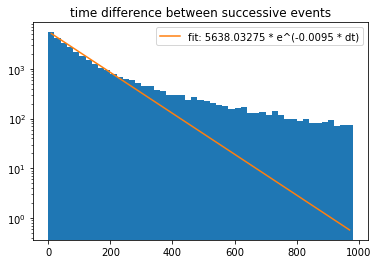

In [74]:
def fit_exp(x, a, b):
    return a * np.exp(-b * x) 

xdata = (np.histogram(dt_ER, bins = np.arange(0,1000,20))[1][:-1]+np.histogram(dt_ER, bins = np.arange(0,1000,20))[1][1:])/2
ydata = np.histogram(dt_ER, bins = np.arange(0,1000,20))[0]

para_fit = curve_fit(fit_exp, xdata, ydata)[0]

y_fit = fit_exp(xdata, para_fit[0], para_fit[1])

plt.hist(dt_ER, bins = np.arange(0,1000,20))
plt.plot(xdata, y_fit, label=('fit: %.5f * e^(-%.4f * dt)' % (para_fit[0],para_fit[1])))
plt.legend()
plt.yscale('log')
plt.title('time difference between successive events')
plt.show()

In [75]:
np.shape(df_ER)

(42251, 264)

In [76]:
ER_events_l = df_ER[(df_ER['energy']<=30)]
ER_events_peak1 = df_ER[(df_ER['energy']<50) & (df_ER['energy']>30)]
ER_events_m = df_ER[(df_ER['energy']<=142) & (df_ER['energy']>=50)]
ER_events_peak2 = df_ER[(df_ER['energy']>142) & (df_ER['energy']<185)]
ER_events_u = df_ER[(df_ER['energy']>=185)]

In [77]:
dt_ER_l = []
i = 0

for j in tqdm(range(0, np.shape(dsets)[0])):
    start = dsets.start[5872-j].replace(tzinfo=timezone.utc).timestamp()
    end = dsets.end[5872-j].replace(tzinfo=timezone.utc).timestamp()
    if ER_events_l['event_time'].values[i+1]*1e-9 < end:
        print(i)
        if ER_events_l['event_time'].values[i]*1e-9 > start:
            dt_ER_l.append((ER_events_l['event_time'].values[i+1]-ER_events_l['event_time'].values[i])*1e-9)
    if ER_events_l['event_time'].values[i+1]*1e-9 > end:
        print(j)
        j = j-1

  6%|▋         | 375/5873 [00:00<00:01, 3744.36it/s]

0
1
2
3
4
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


 19%|█▉        | 1115/5873 [00:00<00:01, 3702.09it/s]


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0

 32%|███▏      | 1861/5873 [00:00<00:01, 3708.09it/s]

...


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0

 83%|████████▎ | 4866/5873 [00:01<00:00, 3746.07it/s]


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0

100%|██████████| 5873/5873 [00:01<00:00, 3729.54it/s]


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0

In [78]:
dt_ER_l = []
j = 5872
start = dsets.start[j].replace(tzinfo=timezone.utc).timestamp()
end = dsets.end[j].replace(tzinfo=timezone.utc).timestamp()

for i in tqdm(range(0, np.shape(ER_events_l)[0]-1)):    
    while ER_events_l['event_time'].values[i+1]*1e-9 > end:
        j = j - 1
        start = dsets.start[j].replace(tzinfo=timezone.utc).timestamp()
        end = dsets.end[j].replace(tzinfo=timezone.utc).timestamp()
    if j == 3272:
        break
    if ER_events_l['event_time'].values[i]*1e-9 > start:
        dt_ER_l.append((ER_events_l['event_time'].values[i+1]-ER_events_l['event_time'].values[i])*1e-9)
        


 34%|███▎      | 424/1260 [00:00<00:00, 2151.69it/s]


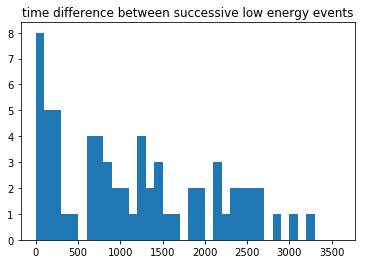

In [79]:
plt.hist(dt_ER_l, bins = np.arange(0,3601,100))
plt.title('time difference between successive low energy events')
plt.show()

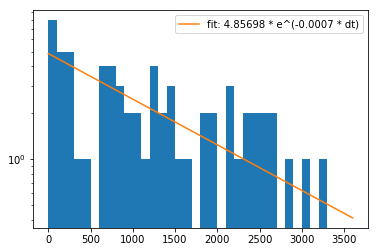

In [80]:
def fit_exp(x, a, b):
    return a * np.exp(-b * x) 

xdata = (np.histogram(dt_ER_l, bins = np.arange(0,3601,100))[1][:-1]+np.histogram(dt_ER_l, bins = np.arange(0,3601,100))[1][1:])/2
ydata = np.histogram(dt_ER_l, bins = np.arange(0,3601,100))[0]

para_fit = curve_fit(fit_exp, xdata, ydata, p0=[50, 0.001])[0]

y_fit = fit_exp(np.arange(0,3601,100), para_fit[0], para_fit[1])

plt.hist(dt_ER_l, bins = np.arange(0,3601,100))
plt.plot(np.arange(0,3601,100), y_fit, label=('fit: %.5f * e^(-%.4f * dt)' % (para_fit[0],para_fit[1])))
plt.legend()
plt.yscale('log')
plt.show()

 50%|█████     | 1148/2284 [00:00<00:00, 4324.91it/s]


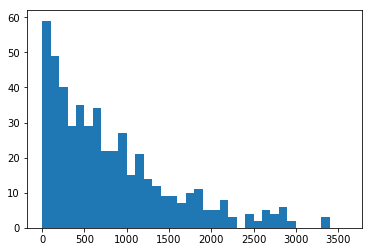

In [81]:
dt_ER_u = []
j = 5872
start = dsets.start[j].replace(tzinfo=timezone.utc).timestamp()
end = dsets.end[j].replace(tzinfo=timezone.utc).timestamp()

for i in tqdm(range(0, np.shape(ER_events_u)[0]-1)):    
    while ER_events_u['event_time'].values[i+1]*1e-9 > end:
        j = j - 1
        start = dsets.start[j].replace(tzinfo=timezone.utc).timestamp()
        end = dsets.end[j].replace(tzinfo=timezone.utc).timestamp()
    if j == 3272:
        break
    if ER_events_u['event_time'].values[i]*1e-9 > start:
        dt_ER_u.append((ER_events_u['event_time'].values[i+1]-ER_events_u['event_time'].values[i])*1e-9)
        
plt.hist(dt_ER_u, bins = np.arange(0,3601,100))
plt.show()

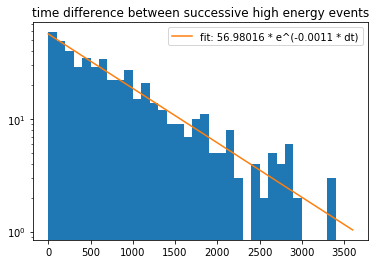

In [82]:
def fit_exp(x, a, b):
    return a * np.exp(-b * x) 

xdata = (np.histogram(dt_ER_u, bins = np.arange(0,3601,100))[1][:-1]+np.histogram(dt_ER_u, bins = np.arange(0,3601,100))[1][1:])/2
ydata = np.histogram(dt_ER_u, bins = np.arange(0,3601,100))[0]

para_fit = curve_fit(fit_exp, xdata, ydata, p0=[50, 0.001])[0]

y_fit = fit_exp(np.arange(0,3601,100), para_fit[0], para_fit[1])

plt.hist(dt_ER_u, bins = np.arange(0,3601,100))
plt.plot(np.arange(0,3601,100), y_fit, label=('fit: %.5f * e^(-%.4f * dt)' % (para_fit[0],para_fit[1])))
plt.legend()
plt.yscale('log')
plt.title('time difference between successive high energy events')
plt.show()

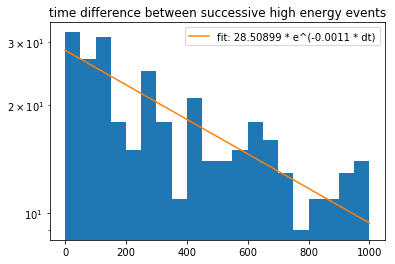

In [83]:
def fit_exp(x, a, b):
    return a * np.exp(-b * x) 

xdata = (np.histogram(dt_ER_u, bins = np.arange(0,1001,50))[1][:-1]+np.histogram(dt_ER_u, bins = np.arange(0,1001,50))[1][1:])/2
ydata = np.histogram(dt_ER_u, bins = np.arange(0,1001,50))[0]

para_fit = curve_fit(fit_exp, xdata, ydata, p0=[50, 0.001])[0]

y_fit = fit_exp(np.arange(0,1001,50), para_fit[0], para_fit[1])

plt.hist(dt_ER_u, bins = np.arange(0,1001,50))
plt.plot(np.arange(0,1001,50), y_fit, label=('fit: %.5f * e^(-%.4f * dt)' % (para_fit[0],para_fit[1])))
plt.legend()
plt.yscale('log')
plt.title('time difference between successive high energy events')
plt.show()

 57%|█████▋    | 4007/7026 [00:00<00:00, 12157.34it/s]


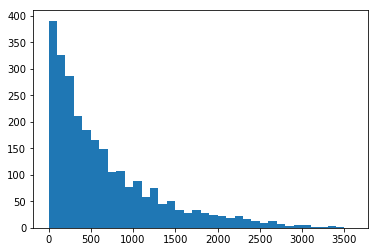

In [84]:
dt_ER_m = []
j = 5872
start = dsets.start[j].replace(tzinfo=timezone.utc).timestamp()
end = dsets.end[j].replace(tzinfo=timezone.utc).timestamp()

for i in tqdm(range(0, np.shape(ER_events_m)[0]-1)):    
    while ER_events_m['event_time'].values[i+1]*1e-9 > end:
        j = j - 1
        start = dsets.start[j].replace(tzinfo=timezone.utc).timestamp()
        end = dsets.end[j].replace(tzinfo=timezone.utc).timestamp()
    if j == 3272:
        break
    if ER_events_m['event_time'].values[i]*1e-9 > start:
        dt_ER_m.append((ER_events_m['event_time'].values[i+1]-ER_events_m['event_time'].values[i])*1e-9)
        
plt.hist(dt_ER_m, bins = np.arange(0,3601,100))
plt.show()

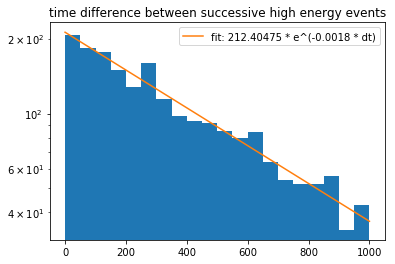

In [85]:
def fit_exp(x, a, b):
    return a * np.exp(-b * x) 

xdata = (np.histogram(dt_ER_m, bins = np.arange(0,1001,50))[1][:-1]+np.histogram(dt_ER_m, bins = np.arange(0,1001,50))[1][1:])/2
ydata = np.histogram(dt_ER_m, bins = np.arange(0,1001,50))[0]

para_fit = curve_fit(fit_exp, xdata, ydata, p0=[50, 0.001])[0]

y_fit = fit_exp(np.arange(0,1001,50), para_fit[0], para_fit[1])

plt.hist(dt_ER_m, bins = np.arange(0,1001,50))
plt.plot(np.arange(0,1001,50), y_fit, label=('fit: %.5f * e^(-%.4f * dt)' % (para_fit[0],para_fit[1])))
plt.legend()
plt.yscale('log')
plt.title('time difference between successive high energy events')
plt.show()


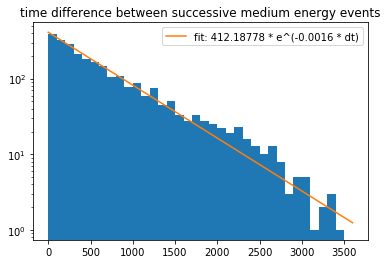

In [86]:
def fit_exp(x, a, b):
    return a * np.exp(-b * x) 

xdata = (np.histogram(dt_ER_m, bins = np.arange(0,3601,100))[1][:-1]+np.histogram(dt_ER_m, bins = np.arange(0,3601,100))[1][1:])/2
ydata = np.histogram(dt_ER_m, bins = np.arange(0,3601,100))[0]

para_fit = curve_fit(fit_exp, xdata, ydata, p0=[50, 0.001])[0]

y_fit = fit_exp(np.arange(0,3601,100), para_fit[0], para_fit[1])

plt.hist(dt_ER_m, bins = np.arange(0,3601,100))
plt.plot(np.arange(0,3601,100), y_fit, label=('fit: %.5f * e^(-%.4f * dt)' % (para_fit[0],para_fit[1])))
plt.legend()
plt.yscale('log')
plt.title('time difference between successive medium energy events')
plt.show()

In [87]:
time_breaks = []
livetime = []

for i in tqdm(range(0, np.shape(dsets)[0])):
    time = dsets.start[5872-i].replace(tzinfo=timezone.utc).timestamp()
    end = dsets.end[5872-i].replace(tzinfo=timezone.utc).timestamp()
    while time < end - 500:
        time_breaks.append(time)
        time = time + 500
        livetime.append(500)
    time_breaks.append(time)
    livetime.append(end - time)

100%|██████████| 5873/5873 [00:00<00:00, 9955.19it/s]


In [88]:
np.sum(livetime)/(3600*24)

242.2304050925926

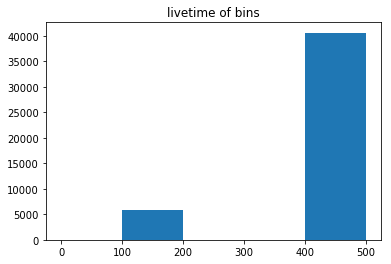

In [89]:
plt.hist(livetime, bins=np.arange(0, 600, 100))
plt.title("livetime of bins")
plt.show()

In [90]:
number = []
j = 0

for i in tqdm(range(0, np.shape(time_breaks)[0]-1)):
    n = 0
    while ER_events_l['event_time'].values[j]*1e-9 < time_breaks[i+1]:
        n = n + 1
        j = j + 1 
    if livetime[i] == 500:
        number.append(n)    

 67%|██████▋   | 30960/46486 [00:00<00:00, 154347.91it/s]


IndexError: index 1261 is out of bounds for axis 0 with size 1261

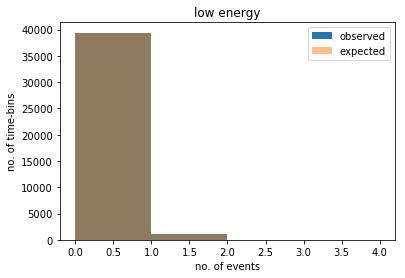

In [127]:
plt.hist(number, bins = np.arange(0, 5, 1), label = "observed")
#generate Poisson distribution with sample size 10000
x = poisson.rvs(mu=0.029, size=np.shape(number)[0])

#create plot of Poisson distribution
plt.hist(x, bins = np.arange(0, 5, 1), label = "expected", alpha = 0.5)

plt.title('low energy')
plt.xlabel('no. of events')
plt.ylabel('no. of time-bins')
plt.legend()
plt.show()

In [128]:
for i in (range(0, np.shape(dsets)[0])):
    if (dsets.start[i].year == 2017 and dsets.start[i].month == 7 and dsets.start[i].day == 16):
        print(i)
    if (dsets.start[i].year == 2017 and dsets.start[i].month == 8 and dsets.start[i].day == 30):
        print(i)

3272
3273
3274
3275
3276
3277
3278
3279
3280
3281
3282
3283
3284
3285
3286
3936


In [ ]:
dsets.start[3272]

In [ ]:
dsets.start[3936]

In [129]:
time_breaks = []
livetime = []

for i in tqdm(range(3272, 3937)):
    time = dsets.start[5872-i].replace(tzinfo=timezone.utc).timestamp()
    end = dsets.end[5872-i].replace(tzinfo=timezone.utc).timestamp()
    while time < end - 500:
        time_breaks.append(time)
        time = time + 500
        livetime.append(500)
    time_breaks.append(time)
    livetime.append(end - time)

100%|██████████| 665/665 [00:00<00:00, 6968.00it/s]


In [130]:
number = []
j = 0

while ER_events_l['event_time'].values[j]*1e-9 < time_breaks[0]:
    j = j + 1 

print(j)
print(ER_events_l['event_time'].values[j]*1e-9 - time_breaks[0])
    
for i in tqdm(range(0, np.shape(time_breaks)[0]-1)):
    n = 0
    while ER_events_l['event_time'].values[j]*1e-9 < time_breaks[i+1]:
        n = n + 1
        j = j + 1 
    #if livetime[i] == 500:
    number.append(n)    

100%|██████████| 5283/5283 [00:00<00:00, 141653.99it/s]

741
1917.90340018


In [131]:
np.max(number)

2

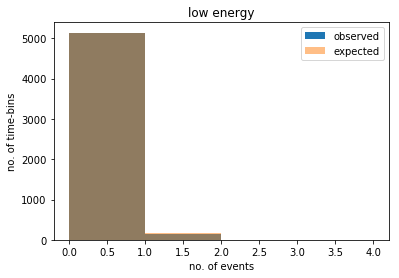

In [132]:
plt.hist(number, bins = np.arange(0, 5, 1), label = "observed")
#generate Poisson distribution with sample size 10000
x = poisson.rvs(mu=0.029, size=np.shape(number)[0])

#create plot of Poisson distribution
plt.hist(x, bins = np.arange(0, 5, 1), label = "expected", alpha = 0.5)

plt.title('low energy')
plt.xlabel('no. of events')
plt.ylabel('no. of time-bins')
plt.legend()
plt.show()

In [133]:
number = []
j = 0

while ER_events_u['event_time'].values[j]*1e-9 < time_breaks[0]:
    j = j + 1 

print(j)
print(ER_events_u['event_time'].values[j]*1e-9 - time_breaks[0])
    
for i in tqdm(range(0, np.shape(time_breaks)[0]-1)):
    n = 0
    while ER_events_u['event_time'].values[j]*1e-9 < time_breaks[i+1]:
        n = n + 1
        j = j + 1 
    if livetime[i] == 500:
        number.append(n)    

100%|██████████| 5283/5283 [00:00<00:00, 156333.18it/s]

1613
8291.69888163


In [134]:
np.max(number)

2

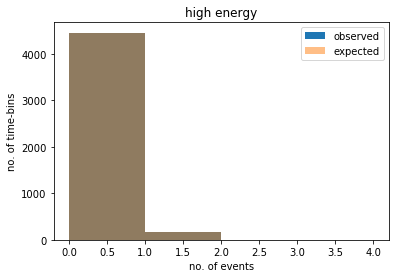

In [135]:
plt.hist(number, bins = np.arange(0, 5, 1), label = "observed")
#generate Poisson distribution with sample size 10000
x = poisson.rvs(mu=0.035, size=np.shape(number)[0])

#create plot of Poisson distribution
plt.hist(x, bins = np.arange(0, 5, 1), label = "expected", alpha = 0.5)

plt.title('high energy')
plt.xlabel('no. of events')
plt.ylabel('no. of time-bins')
plt.legend()
plt.show()

In [136]:
number = []
j = 0

while ER_events_m['event_time'].values[j]*1e-9 < time_breaks[0]:
    j = j + 1 

print(j)
print(ER_events_m['event_time'].values[j]*1e-9 - time_breaks[0])
    
for i in tqdm(range(0, np.shape(time_breaks)[0]-1)):
    n = 0
    while ER_events_m['event_time'].values[j]*1e-9 < time_breaks[i+1]:
        n = n + 1
        j = j + 1 
    if livetime[i] == 500:
        number.append(n)    

100%|██████████| 5283/5283 [00:00<00:00, 111411.43it/s]

4978
2916.93491817


In [137]:
np.max(number)

3

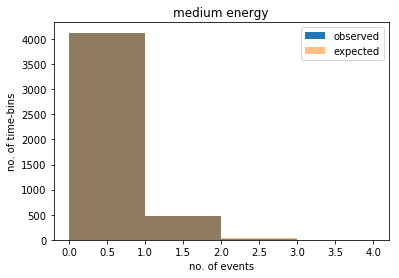

In [138]:
plt.hist(number, bins = np.arange(0, 5, 1), label = "observed")
#generate Poisson distribution with sample size 10000
x = poisson.rvs(mu=0.11, size=np.shape(number)[0])

#create plot of Poisson distribution
plt.hist(x, bins = np.arange(0, 5, 1), label = "expected", alpha = 0.5)

plt.legend()
plt.title('medium energy')
plt.xlabel('no. of events')
plt.ylabel('no. of time-bins')
#plt.yscale('log')
plt.show()

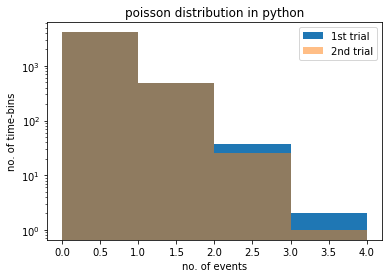

In [139]:
#plt.hist(number, bins = np.arange(0, 5, 1), label = "observed")

x = poisson.rvs(mu=0.125, size=np.shape(number)[0])
plt.hist(x, bins = np.arange(0, 5, 1), label = "1st trial")

x = poisson.rvs(mu=0.125, size=np.shape(number)[0])
plt.hist(x, bins = np.arange(0, 5, 1), label = "2nd trial", alpha = 0.5)

plt.legend()
plt.title('poisson distribution in python')
plt.xlabel('no. of events')
plt.ylabel('no. of time-bins')
plt.yscale('log')
plt.show()

In [ ]:
plt.show()

In [ ]:
number = []
j = 0

while ER_events_peak1['event_time'].values[j]*1e-9 < time_breaks[0]:
    j = j + 1 

print(j)
print(ER_events_peak1['event_time'].values[j]*1e-9 - time_breaks[0])
    
for i in tqdm(range(0, np.shape(time_breaks)[0]-1)):
    n = 0
    while ER_events_peak1['event_time'].values[j]*1e-9 < time_breaks[i+1]:
        n = n + 1
        j = j + 1 
    if livetime[i] == 500:
        number.append(n)

In [ ]:
np.max(number)

In [ ]:
plt.hist(number, bins = np.arange(0, 5, 1), label = "observed")
#generate Poisson distribution with sample size 10000
x = poisson.rvs(mu=0.08, size=np.shape(number)[0])

#create plot of Poisson distribution
plt.hist(x, bins = np.arange(0, 5, 1), label = "expected", alpha = 0.5)

plt.legend()
plt.title('peak1')
plt.show()

In [ ]:
event = []
number = []
j = 0

for i in tqdm(range(0, np.shape(time_breaks)[0]-1)):
    n = 0
    while ER_events_peak2['event_time'].values[j]*1e-9 < time_breaks[i+1]:
        n = n + 1
        j = j + 1 
    number.append(n)
    event.append(n/livetime[i]*500)

In [ ]:
np.max(number)

In [ ]:
plt.hist(number, np.arange(0, 30, 1))
plt.title('peak2')
plt.show()